In [2]:
import numpy as np
import pandas as pd
import re

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, learning_curve, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from wordcloud import WordCloud
from sklearn.metrics import log_loss

Import Dataset from Huggingface

In [2]:
df = pd.read_csv("hf://datasets/sai1908/Mental_Health_Condition_Classification/Mental Health Text Dataset for Emotion and Condition Classification.csv")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Data Cleaning

In [3]:
def clean_text(s):
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = re.sub(r'http\S+|www\.\S+', ' ', s)
    s = re.sub(r'@\w+|#\w+', ' ', s)
    s = re.sub(r'[^a-z\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

In [4]:
df['text_clean'] = df['text'].astype(str).apply(clean_text)

Encode labels


In [5]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['status'])

In [6]:
class_names = le.classes_
print("Classes:", class_names)

Classes: ['anxiety' 'bipolar' 'depression' 'normal' 'personality disorder' 'stress'
 'suicidal']


Train-test Split

In [7]:
X = df['text_clean'].values
y = df['label'].values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y)

Build baseline pipeline

In [ ]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1,2),
        max_df=0.95,
        min_df=5,
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        solver='saga',
        max_iter=200,
        random_state= 42,
        n_jobs=1
    ))
])

Training the baseline Model

In [ ]:
base_model = pipeline.fit(X_train, y_train)

Performance Test

In [ ]:
y_pred = base_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names))

                      precision    recall  f1-score   support

             anxiety       0.94      0.95      0.94      3524
             bipolar       0.98      0.94      0.96      2742
          depression       0.71      0.77      0.74      3180
              normal       0.86      0.96      0.91      3214
personality disorder       0.99      0.95      0.97      2783
              stress       0.96      0.90      0.93      3046
            suicidal       0.72      0.66      0.69      2209

            accuracy                           0.88     20698
           macro avg       0.88      0.87      0.88     20698
        weighted avg       0.89      0.88      0.88     20698



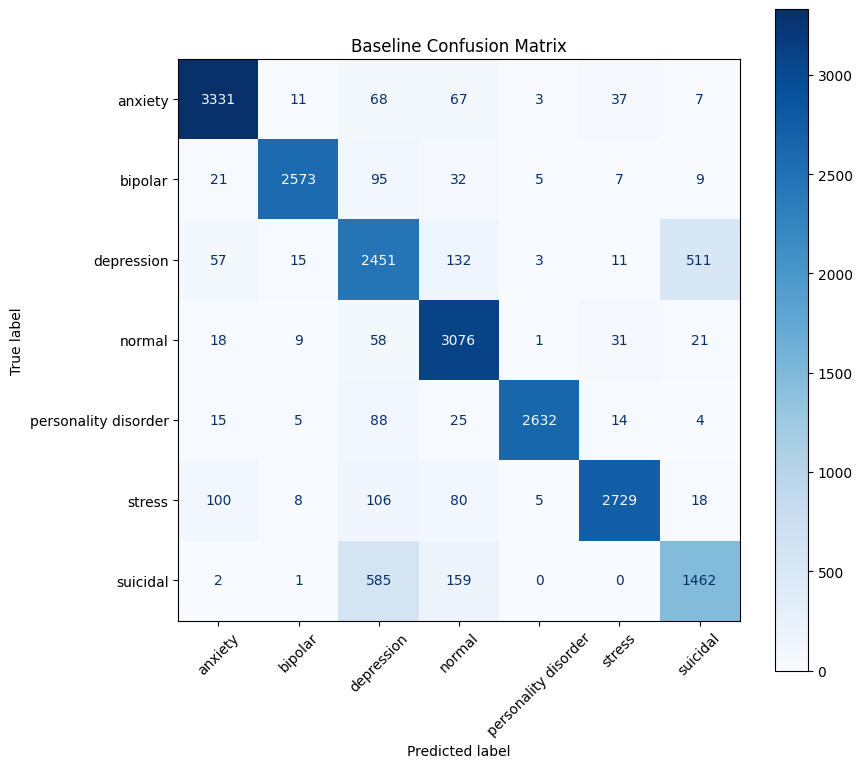

In [ ]:
# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(9,8))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.title("Baseline Confusion Matrix")
plt.tight_layout()
plt.savefig("baseline_confusion_matrix.png")
plt.show()

In [ ]:
y_train_pred = model.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Hyper Parameter Tuning

In [ ]:
param_grid = {
    'tfidf__min_df': [3, 5],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'clf__C': [0.1, 1.0, 5.0],
    'clf__penalty': ['l2'],
    'clf__class_weight': [None, 'balanced']
}

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=1,
    verbose=2
)

In [ ]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END clf__C=0.1, clf__class_weight=None, clf__penalty=l2, tfidf__min_df=3, tfidf__ngram_range=(1, 1); total time=  12.0s
[CV] END clf__C=0.1, clf__class_weight=None, clf__penalty=l2, tfidf__min_df=3, tfidf__ngram_range=(1, 1); total time=  13.5s
[CV] END clf__C=0.1, clf__class_weight=None, clf__penalty=l2, tfidf__min_df=3, tfidf__ngram_range=(1, 1); total time=  32.4s
[CV] END clf__C=0.1, clf__class_weight=None, clf__penalty=l2, tfidf__min_df=3, tfidf__ngram_range=(1, 1); total time=  12.2s
[CV] END clf__C=0.1, clf__class_weight=None, clf__penalty=l2, tfidf__min_df=3, tfidf__ngram_range=(1, 1); total time=  10.9s
[CV] END clf__C=0.1, clf__class_weight=None, clf__penalty=l2, tfidf__min_df=3, tfidf__ngram_range=(1, 2); total time=  26.3s
[CV] END clf__C=0.1, clf__class_weight=None, clf__penalty=l2, tfidf__min_df=3, tfidf__ngram_range=(1, 2); total time=  27.5s
[CV] END clf__C=0.1, clf__class_weight=None, clf__penalty=l2, t

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_df=0.95, min_df=5,
                                                        ngram_range=(1, 2),
                                                        sublinear_tf=True)),
                                       ('clf',
                                        LogisticRegression(max_iter=200,
                                                           n_jobs=1,
                                                           random_state=42,
                                                           solver='saga'))]),
             n_jobs=1,
             param_grid={'clf__C': [0.1, 1.0, 5.0],
                         'clf__class_weight': [None, 'balanced'],
                         'clf__penalty': ['l2'], 'tfidf__min_df': [3, 5],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='f1_macro', verbose=2)

In [ ]:
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'clf__C': 5.0, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}
Best CV score: 0.8805314369781522


Evaluate best model on test set

In [ ]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
print("Classification report (best model):")
print(classification_report(y_test, y_pred_best, target_names=class_names))

Classification report (best model):
                      precision    recall  f1-score   support

             anxiety       0.95      0.95      0.95      3524
             bipolar       0.98      0.95      0.96      2742
          depression       0.74      0.74      0.74      3180
              normal       0.89      0.95      0.92      3214
personality disorder       0.99      0.96      0.97      2783
              stress       0.96      0.91      0.93      3046
            suicidal       0.69      0.73      0.71      2209

            accuracy                           0.89     20698
           macro avg       0.88      0.88      0.88     20698
        weighted avg       0.89      0.89      0.89     20698



In [17]:
print("Micro Precision:", precision_score(y_test, y_pred, average="micro"))
print("Macro Precision:", precision_score(y_test, y_pred, average="macro"))
print("Weighted Precision:", precision_score(y_test, y_pred, average="weighted"))

print("Micro Recall:", recall_score(y_test, y_pred, average="micro"))
print("Macro Recall:", recall_score(y_test, y_pred, average="macro"))
print("Weighted Recall:", recall_score(y_test, y_pred, average="weighted"))

print("Micro F1:", f1_score(y_test, y_pred, average="micro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred, average="weighted"))

Micro Precision: 0.8876219924630399
Macro Precision: 0.8843274015115318
Weighted Precision: 0.8899338437964347
Micro Recall: 0.8876219924630399
Macro Recall: 0.8821137109472988
Weighted Recall: 0.8876219924630399
Micro F1: 0.8876219924630399
Macro F1: 0.8828671371797757
Weighted F1: 0.8884300131910042


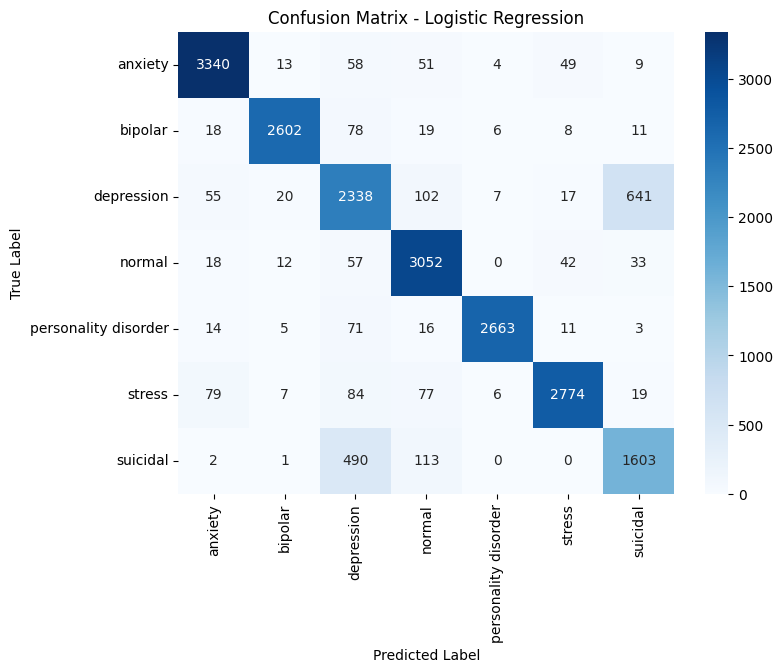

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",  xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

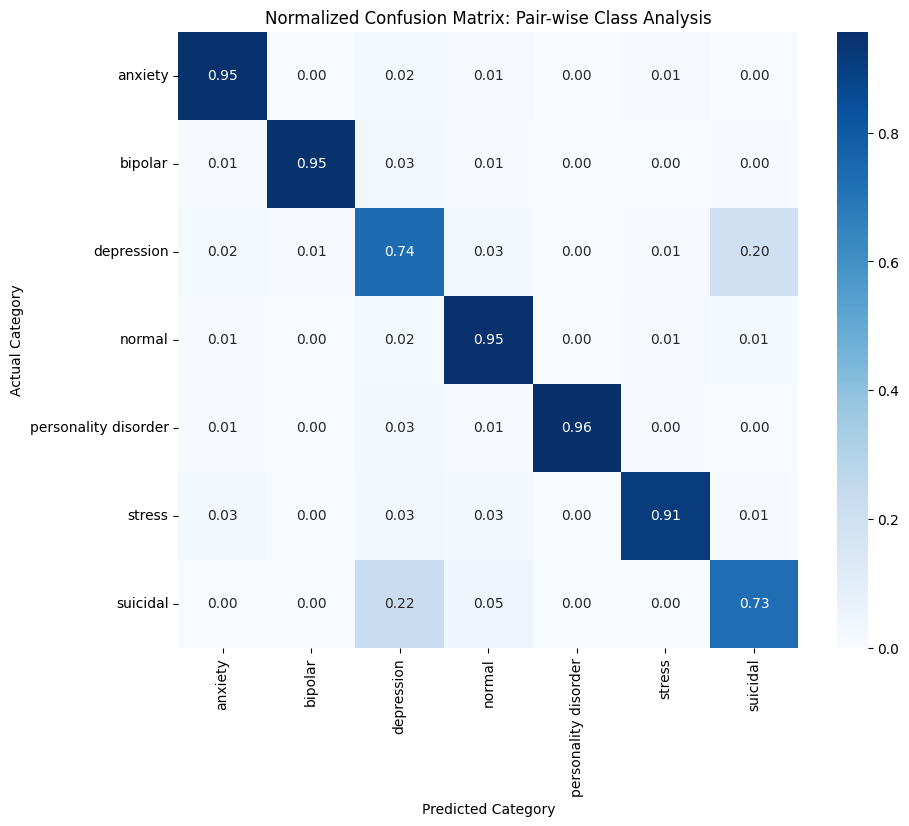

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Get predictions
y_pred = model.predict(X_test)

# 2. Generate the confusion matrix
# 'classes' should be your list of labels: ['anxiety', 'bipolar', 'depression', ...]
cm = confusion_matrix(y_test, y_pred)

# 3. Normalize the matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 4. Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Normalized Confusion Matrix: Pair-wise Class Analysis')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

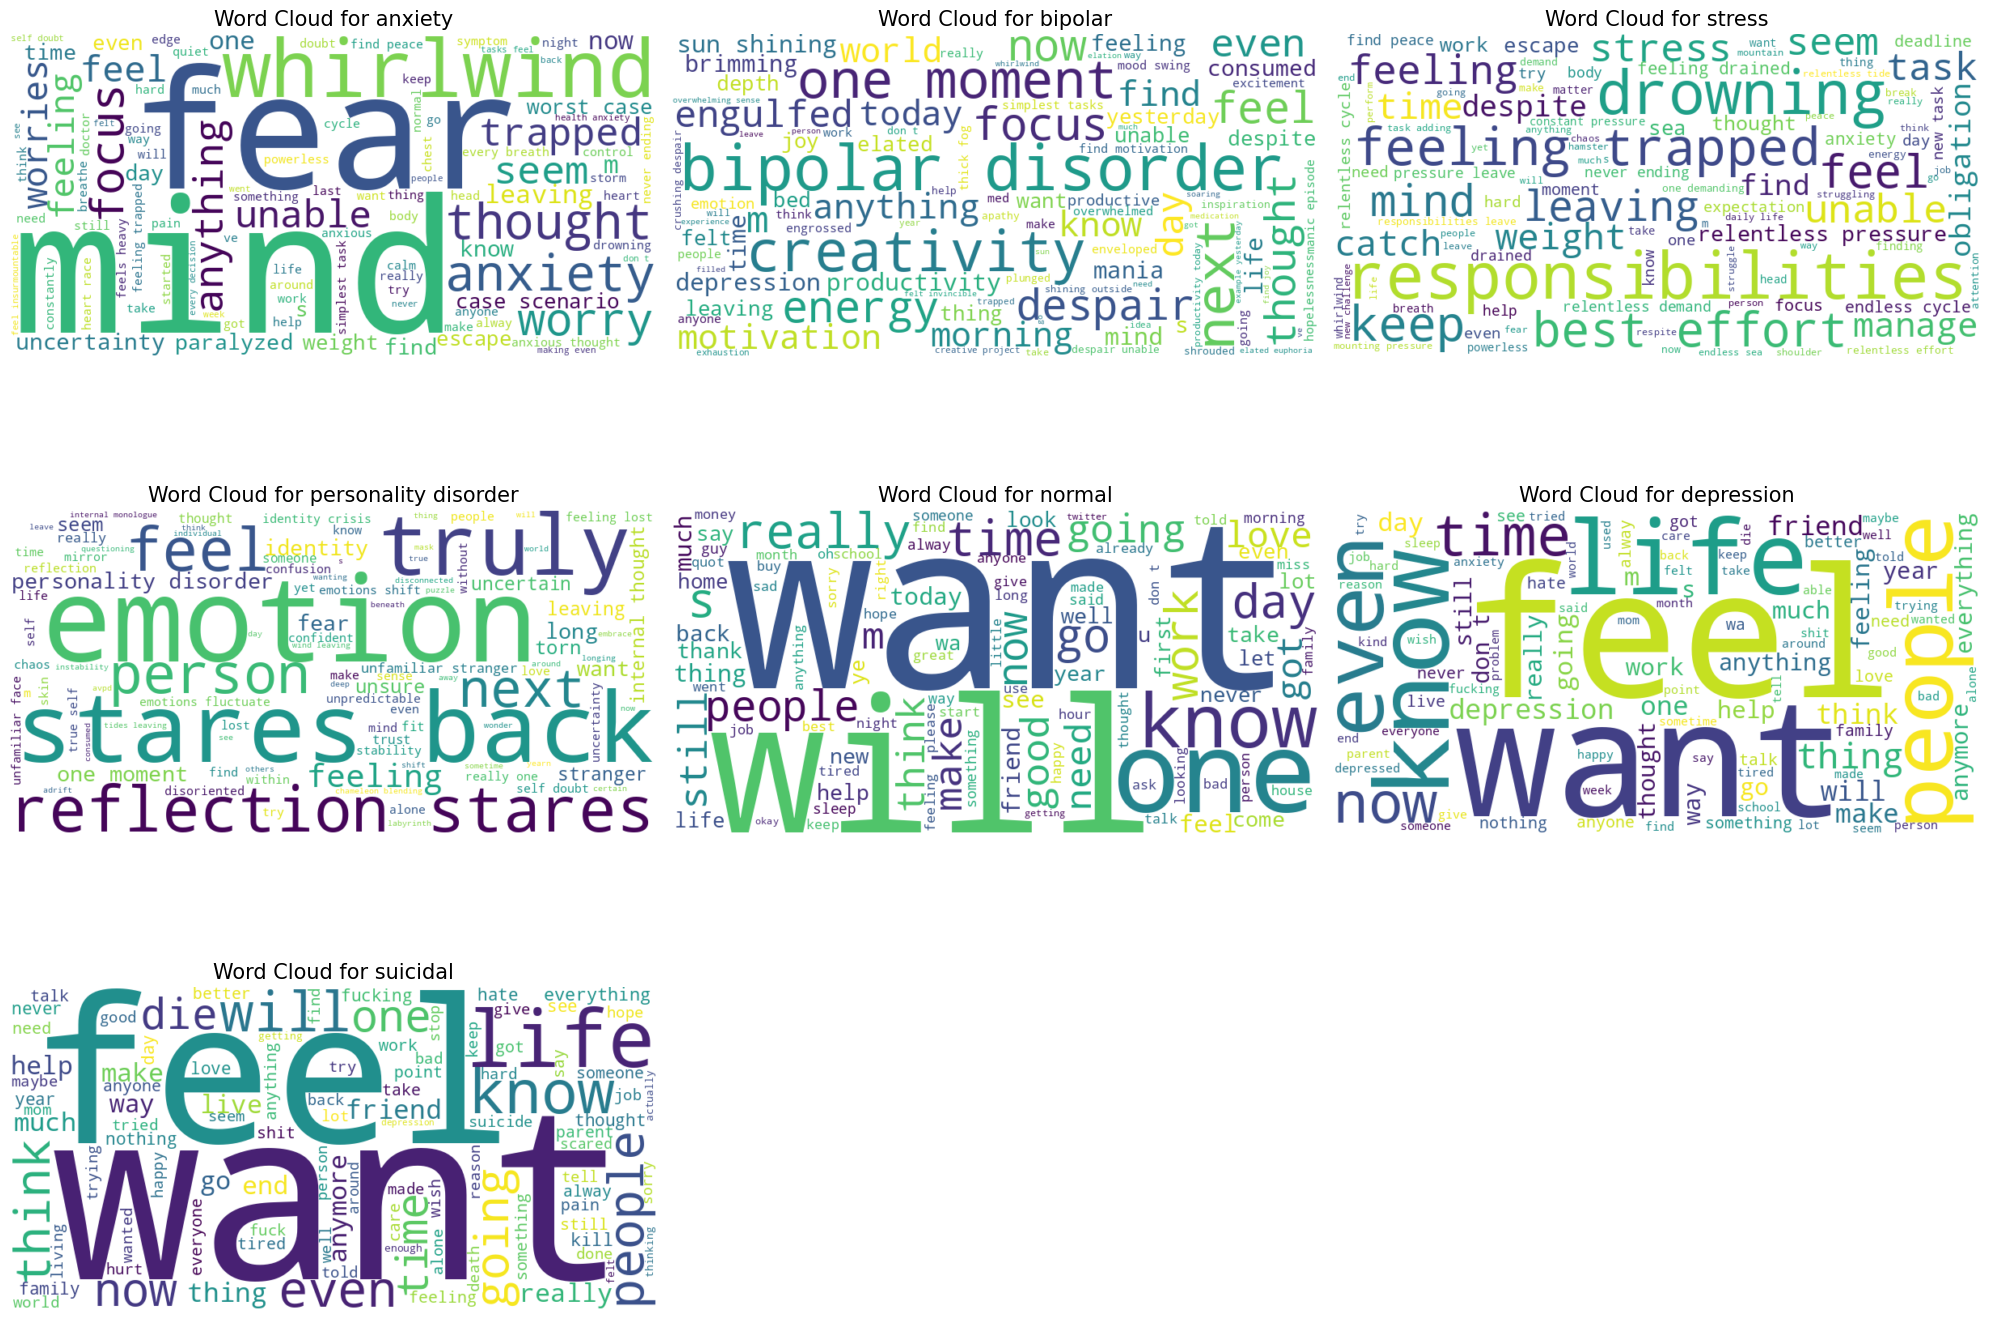

In [ ]:
# Get unique classes
classes = df['status'].unique()

# Plot word cloud for each class
plt.figure(figsize=(20, 15))

for i, cls in enumerate(classes, 1):
    plt.subplot(3, 3, i)  # adjust grid (3x3) for 7 classes
    text = " ".join(df[df['status'] == cls]['text'].values)
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=100,
        colormap='viridis'
    ).generate(text)

    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for {cls}", fontsize=15)

plt.tight_layout()
plt.show()

Save the Model

In [ ]:
os.makedirs('models', exist_ok=True)
joblib.dump(best_model, 'models/logreg_tfidf_best.pkl')

['models/logreg_tfidf_best.pkl']

In [9]:
import joblib

model = joblib.load("/content/logreg_tfidf_best.pkl")

In [21]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

In [ ]:
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

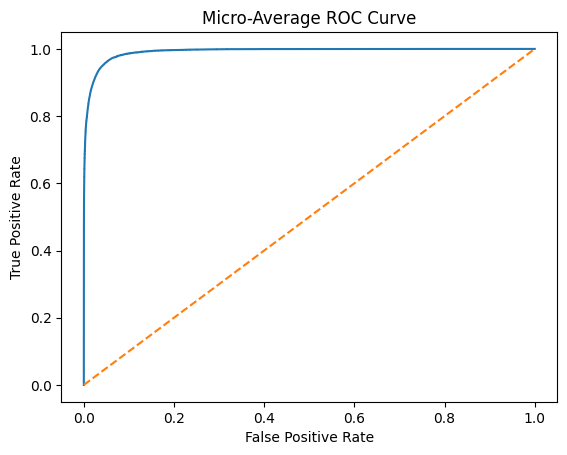

In [ ]:
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-Average ROC Curve")
plt.show()

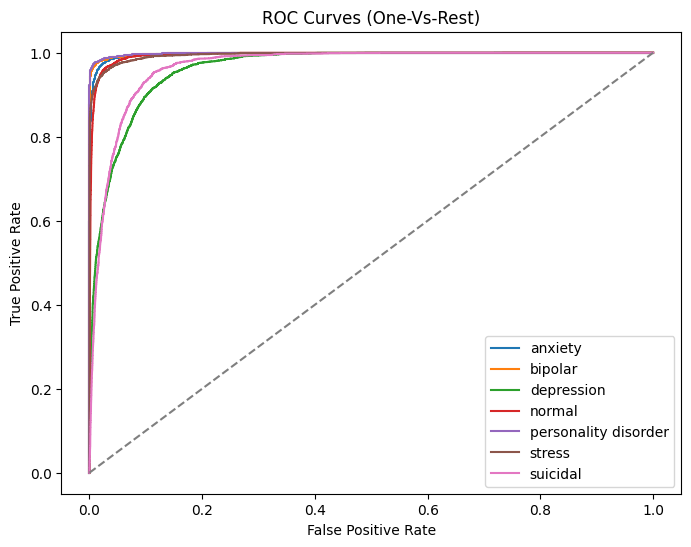

In [ ]:
plt.figure(figsize=(8,6))

for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f"{class_names[i]}")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-Vs-Rest)")
plt.legend()
plt.show()

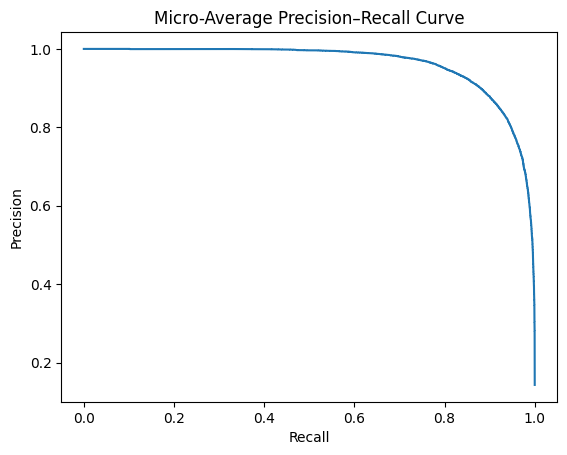

In [ ]:
precision, recall, _ = precision_recall_curve(
    y_test_bin.ravel(),
    y_prob.ravel()
)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Micro-Average Precision–Recall Curve")
plt.show()


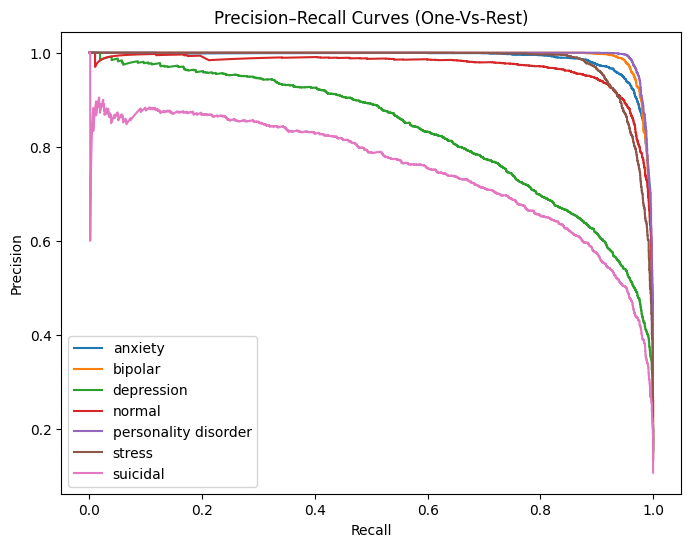

In [ ]:
plt.figure(figsize=(8,6))

for i in range(len(classes)):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )
    plt.plot(recall, precision, label=f"{class_names[i]}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves (One-Vs-Rest)")
plt.legend()
plt.show()

In [23]:
from sklearn.metrics import roc_auc_score

# Get predictions for the training set
y_prob_train = model.predict_proba(X_train)

# Calculate Macro AUC for both
auc_train = roc_auc_score(y_train, y_prob_train, average="macro", multi_class="ovr")
auc_test = roc_auc_score(y_test, y_prob, average="macro", multi_class="ovr")

print(f"Training Macro AUC: {auc_train:.4f}")
print(f"Test Macro AUC:     {auc_test:.4f}")
print(f"Difference:         {auc_train - auc_test:.4f}")

Training Macro AUC: 0.9998
Test Macro AUC:     0.9879
Difference:         0.0120


In [22]:
y_train_pred = model.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Train Accuracy: 0.994371300881749
Test Accuracy: 0.8876219924630399


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=skf,
    scoring="f1_macro"
)

print("CV Macro F1 Scores:", cv_scores)
print("Mean CV Macro F1:", cv_scores.mean())

CV Macro F1 Scores: [0.87942045 0.87912844 0.88090873 0.88098201 0.88221755]
Mean CV Macro F1: 0.8805314369781522


In [11]:
# Calculate global log loss
overall_loss = log_loss(y_test, y_prob)
print(f"Overall Log Loss: {overall_loss}")

Overall Log Loss: 0.30686998037791335


In [ ]:
sample_texts = [
    "I feel extremely anxious and worried all the time",
    "Life feels empty and I have lost all motivation",
    "I feel completely normal and content with life",
    "I am overwhelmed with work and constant pressure",
    "My mood changes suddenly from high energy to sadness",
    "I struggle with my identity and emotional instability",
    "I feel like ending my life and escaping everything"
]

probs = model.predict_proba(sample_texts)
pred_indices = probs.argmax(axis=1)
pred_labels = le.inverse_transform(pred_indices)

for text, label, prob in zip(sample_texts, pred_labels, probs):
    confidence = prob.max()

    # Risk logic (optional but recommended)
    if label == "suicidal" and confidence >= 0.65:
        risk = "HIGH RISK"
    elif confidence < 0.55:
        risk = "UNCERTAIN"
    else:
        risk = "MODERATE-HIGH"

    print("Text:", text)
    print("Predicted class:", label)
    print(f"Confidence: {confidence:.2%}")
    print("Risk level:", risk)
    print("-" * 60)

Text: I feel extremely anxious and worried all the time
Predicted class: anxiety
Confidence: 93.42%
Risk level: MODERATE-HIGH
------------------------------------------------------------
Text: Life feels empty and I have lost all motivation
Predicted class: depression
Confidence: 39.11%
Risk level: UNCERTAIN
------------------------------------------------------------
Text: I feel completely normal and content with life
Predicted class: depression
Confidence: 63.72%
Risk level: MODERATE-HIGH
------------------------------------------------------------
Text: I am overwhelmed with work and constant pressure
Predicted class: stress
Confidence: 73.57%
Risk level: MODERATE-HIGH
------------------------------------------------------------
Text: My mood changes suddenly from high energy to sadness
Predicted class: normal
Confidence: 48.96%
Risk level: UNCERTAIN
------------------------------------------------------------
Text: I struggle with my identity and emotional instability
Predicted cl